In [1]:
# Task 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [13]:
# Task 2: Load Dataset

df = pd.read_excel(
    "EastWestAirlines.xlsx",
    sheet_name="data"
)

print(df.head())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


In [14]:
# Task 3: Display Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None


In [15]:
# Task 4: Statistical Summary

print(df.describe())

               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.000000   
mean   2014.819455  7.360133e+04    144.114529     2.059515     1.014504   
std    1160.764358  1.007757e+05    773.663804     1.376919     0.147650   
min       1.000000  0.000000e+00      0.000000     1.000000     1.000000   
25%    1010.500000  1.852750e+04      0.000000     1.000000     1.000000   
50%    2016.000000  4.309700e+04      0.000000     1.000000     1.000000   
75%    3020.500000  9.240400e+04      0.000000     3.000000     1.000000   
max    4021.000000  1.704838e+06  11148.000000     5.000000     3.000000   

         cc3_miles    Bonus_miles  Bonus_trans  Flight_miles_12mo  \
count  3999.000000    3999.000000   3999.00000        3999.000000   
mean      1.012253   17144.846212     11.60190         460.055764   
std       0.195241   24150.967826      9.60381        1400.209171   
min       1.000000       0.000000      

In [16]:
# Task 5: Check Missing Values

print(df.isnull().sum())

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


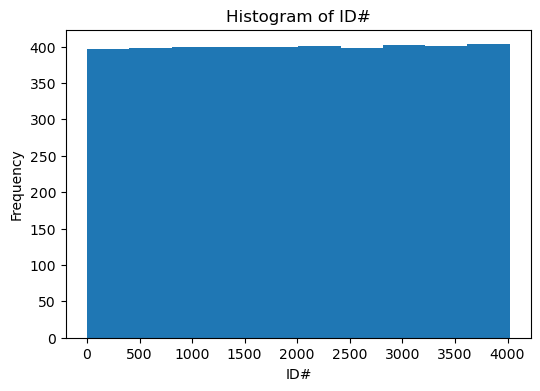

In [18]:
# Task 6: Histogram

numeric_column = df.select_dtypes(include=np.number).columns[0]

plt.figure(figsize=(6,4))

plt.hist(df[numeric_column], bins=10)

plt.title(f"Histogram of {numeric_column}")
plt.xlabel(numeric_column)
plt.ylabel("Frequency")

plt.show()

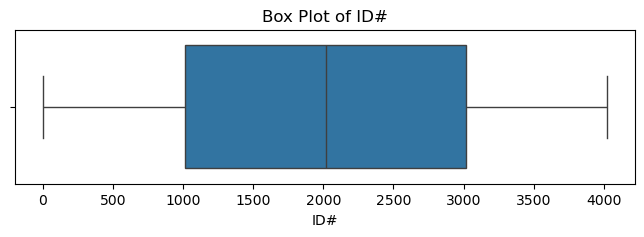

In [19]:
# Task 7: Box Plot

numeric_column = df.select_dtypes(include=np.number).columns[0]

plt.figure(figsize=(8,2))

sns.boxplot(x=df[numeric_column])

plt.title(f"Box Plot of {numeric_column}")

plt.show()

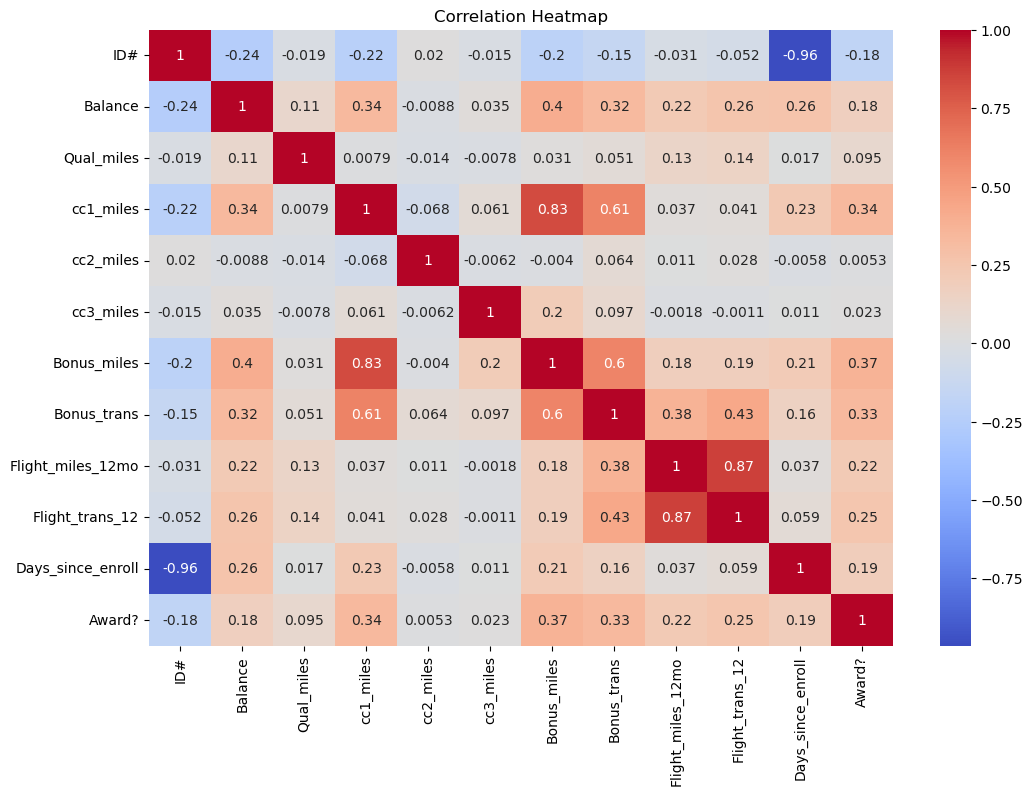

In [20]:
# Task 8: Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [21]:
# Task 9: Handle Missing Values

df = df.fillna(df.mean(numeric_only=True))

print(df.isnull().sum())

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [22]:
# Task 10: Remove Outliers using IQR

Q1 = numeric_df.quantile(0.25)

Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~((numeric_df < (Q1 - 1.5 * IQR)) |
      (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)
]

print(df.shape)

(2875, 12)


In [23]:
# Task 11: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df.select_dtypes(include=np.number)
)

print(scaled_data[:5])

[[-1.83464329 -0.43885929  0.         -0.71905467  0.          0.
  -0.78313072 -1.08173169 -0.37883719 -0.40970772  1.50369284 -0.62307163]
 [-1.83377495 -0.64773487  0.         -0.71905467  0.          0.
  -0.78012963 -0.9527351  -0.37883719 -0.40970772  1.48803468 -0.62307163]
 [-1.83290661 -0.1287733   0.         -0.71905467  0.          0.
  -0.49407535 -0.69474194 -0.37883719 -0.40970772  1.52032964 -0.62307163]
 [-1.83203826 -0.75260689  0.         -0.71905467  0.          0.
  -0.75926846 -1.08173169 -0.37883719 -0.40970772  1.4802056  -0.62307163]
 [-1.83030158 -0.71401924  0.         -0.71905467  0.          0.
  -0.79586701 -1.21072827 -0.37883719 -0.40970772  1.47531242 -0.62307163]]


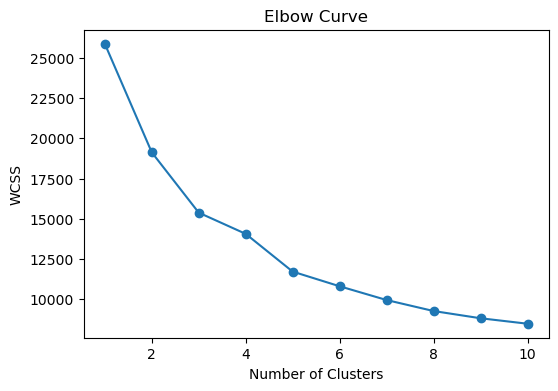

In [24]:
# Task 12: Elbow Method for K-Means

from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [25]:
# Task 13: Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_clusters = kmeans.fit_predict(scaled_data)

print(kmeans_clusters[:10])

[1 1 1 1 1 2 0 1 2 1]


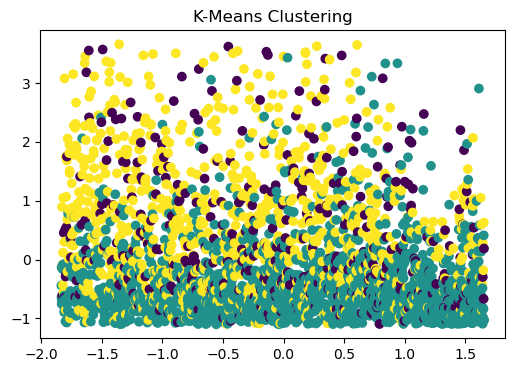

In [26]:
# Task 14: Visualize K-Means Clusters

plt.figure(figsize=(6,4))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=kmeans_clusters
)

plt.title("K-Means Clustering")

plt.show()

In [27]:
# Task 15: Evaluate K-Means Clustering

from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    scaled_data,
    kmeans_clusters
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.30830264215957265


In [28]:
# Task 16: Apply DBSCAN Clustering

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(scaled_data)

print(dbscan_clusters[:10])

[0 0 0 0 0 0 1 0 0 0]


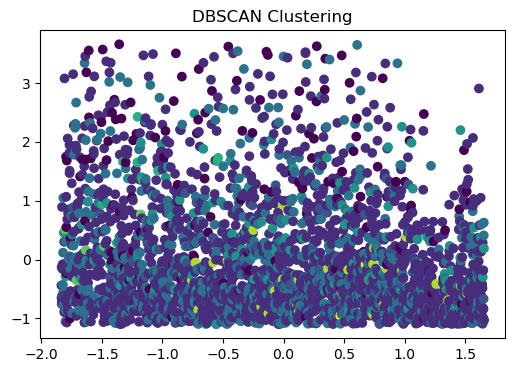

In [29]:
# Task 17: Visualize DBSCAN Clusters

plt.figure(figsize=(6,4))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=dbscan_clusters
)

plt.title("DBSCAN Clustering")

plt.show()

In [30]:
# Task 18: Evaluate DBSCAN Clustering

dbscan_score = silhouette_score(
    scaled_data,
    dbscan_clusters
)

print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.20024442589320263


In [31]:
# Task 19: Cluster Analysis and Interpretation

print("K-Means creates fixed number of clusters.")

print("DBSCAN identifies dense regions and detects noise points.")

print("Different clustering methods produced different cluster structures.")

K-Means creates fixed number of clusters.
DBSCAN identifies dense regions and detects noise points.
Different clustering methods produced different cluster structures.


In [32]:
# Task 20: Compare Clustering Results

print("K-Means Silhouette Score:", kmeans_score)

print("DBSCAN Silhouette Score:", dbscan_score)

K-Means Silhouette Score: 0.30830264215957265
DBSCAN Silhouette Score: 0.20024442589320263


In [33]:
# Task 21: Conclusion

print("K-Means and DBSCAN clustering were implemented successfully.")

print("EDA and preprocessing improved understanding of the dataset.")

print("Elbow curve helped determine optimal clusters for K-Means.")

print("DBSCAN effectively detected dense regions and noise points.")

K-Means and DBSCAN clustering were implemented successfully.
EDA and preprocessing improved understanding of the dataset.
Elbow curve helped determine optimal clusters for K-Means.
DBSCAN effectively detected dense regions and noise points.
